# Risk model — results

Logistic regression predicting whether an employee finishes the week over 55 hours. Trained on one
row per *(employee, week, day-of-week known)*, so nothing assumes the data stops on a Wednesday.

Everything below is **walk-forward** — for each week evaluated, the model saw only earlier weeks.

The baseline it has to beat is what a person would do without a model: take the hours per day they
have averaged so far this week, assume the rest of the week matches, flag them if that clears 55.

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from src.config import BREACH_HOURS
from src.db import connect, data_range
from src.features import FEATURES, build_panel, naive_projection
from src.model import backtest, predict_current_week

plt.rcParams.update({"figure.figsize": (11,3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
pd.set_option("display.width", 200)

conn = connect(Path.cwd().parent / "shifts.db")
panel = build_panel(conn)
CURRENT = pd.Timestamp(str(data_range(conn)["current_week_start"]))
result = backtest(panel, CURRENT)

oof = result.frame
wed = oof[oof.cut == 3].copy()
wed["naive"] = naive_projection(wed)
wed["naive_flag"] = (wed.naive > BREACH_HOURS).astype(int)
y = wed.breached.to_numpy()

def auc(y, score):
    y = np.asarray(y); r = pd.Series(np.asarray(score, float)).rank().to_numpy()
    n1, n0 = y.sum(), len(y) - y.sum()
    return (r[y==1].sum() - n1*(n1+1)/2) / (n1*n0)

print(f"evaluated on {len(wed):,} employee-weeks over {wed.week.nunique()} held-out weeks, "
      f"{y.sum()} breaches (base rate {y.mean():.2%})")
print(f"AUC {auc(y, wed.risk):.3f}   Brier {np.mean((wed.risk-y)**2):.4f}   "
      f"mean predicted risk {wed.risk.mean():.4f} vs actual {y.mean():.4f}")

evaluated on 1,491 employee-weeks over 7 held-out weeks, 55 breaches (base rate 3.69%)
AUC 0.800   Brier 0.0341   mean predicted risk 0.0404 vs actual 0.0369


## Does it beat the baseline?

In [8]:
def score(name, flag):
    tp = int(((flag==1)&(y==1)).sum()); n = int(flag.sum())
    pr = tp/n if n else 0.0; rc = tp/y.sum()
    return {"rule": name, "flagged": n, "caught": tp, "missed": int(y.sum()-tp),
            "precision": pr, "recall": rc, "F1": 2*pr*rc/(pr+rc) if pr+rc else 0.0}

print(pd.DataFrame([
    score(f"model, risk >= {result.threshold:.3f}", (wed.risk >= result.threshold).to_numpy().astype(int)),
    score("naive: pace x days left > 55h", wed.naive_flag.to_numpy()),
    score("flag nobody", np.zeros(len(y), int)),
]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nThe naive rule flags {wed.naive_flag.mean():.0%} of the workforce every week.")

                         rule  flagged  caught  missed  precision  recall    F1
         model, risk >= 0.083      183      26      29      0.142   0.473 0.218
naive: pace x days left > 55h      419      33      22      0.079   0.600 0.139
                  flag nobody        0       0      55      0.000   0.000 0.000

The naive rule flags 28% of the workforce every week.


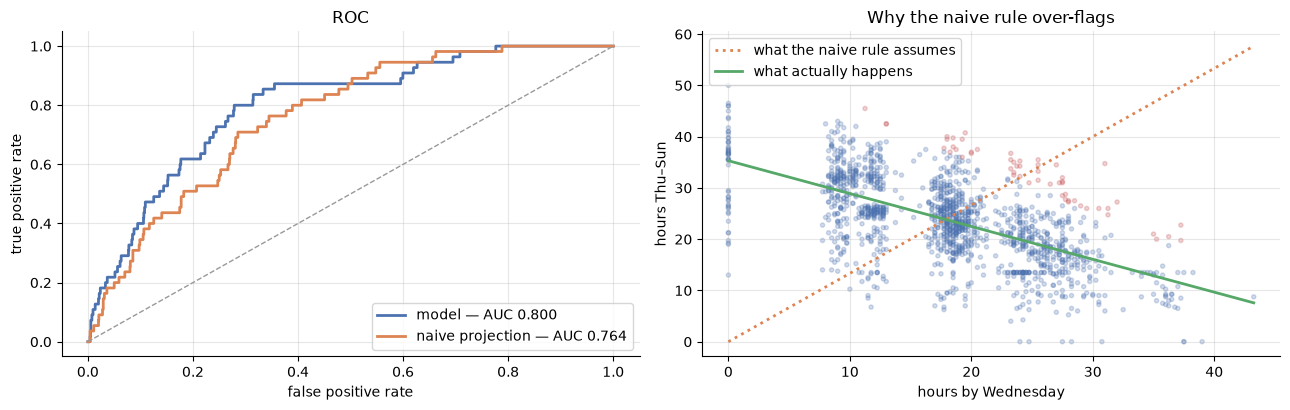

In [9]:
def roc(y, s):
    o = np.argsort(-np.asarray(s, float)); yy = np.asarray(y)[o]
    return np.r_[0, np.cumsum(1-yy)/max((1-yy).sum(),1)], np.r_[0, np.cumsum(yy)/max(yy.sum(),1)]

fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
for label, s, c in [("model", wed.risk, "#4C72B0"), ("naive projection", wed.naive, "#DD8452")]:
    f, t = roc(y, s); ax[0].plot(f, t, color=c, lw=2, label=f"{label} — AUC {auc(y,s):.3f}")
ax[0].plot([0,1],[0,1], color="#999", ls="--", lw=1)
ax[0].set(title="ROC", xlabel="false positive rate", ylabel="true positive rate"); ax[0].legend()

ax[1].scatter(wed.hours_so_far, wed.hours_remaining, s=9, alpha=.25,
              c=np.where(y==1, "#C44E52", "#4C72B0"))
xs = np.linspace(0, wed.hours_so_far.max(), 50)
ax[1].plot(xs, xs*4/3, color="#DD8452", ls=":", lw=2, label="what the naive rule assumes")
ax[1].plot(xs, np.polyval(np.polyfit(wed.hours_so_far, wed.hours_remaining, 1), xs),
           color="#55A868", lw=2, label="what actually happens")
ax[1].set(title="Why the naive rule over-flags", xlabel="hours by Wednesday", ylabel="hours Thu–Sun")
ax[1].legend(); plt.tight_layout(); plt.show()

The naive rule catches more breaches, but only by naming a quarter of the workforce — not something
a contract manager can act on. The model roughly doubles precision for a modest recall cost.

The right-hand plot is the reason. Extrapolating the current pace assumes the back half of the week
matches the front; the fitted line shows it slopes the other way.

## The coefficients

In [10]:
train = panel[(panel.week < CURRENT) & panel.prior_total.notna()]
X = train[FEATURES].to_numpy(); yy = train.breached.to_numpy()
Z = StandardScaler().fit_transform(X)
fit = LogisticRegression(max_iter=2000, C=0.5).fit(Z, yy)

p = fit.predict_proba(Z)[:,1]; W = p*(1-p)
D = np.column_stack([np.ones(len(Z)), Z])
se = np.sqrt(np.diag(np.linalg.pinv(D.T @ (D*W[:,None]))))[1:]
est = fit.coef_[0]; z = est/se

def vif(Z, j):
    others = np.column_stack([np.ones(len(Z)), np.delete(Z, j, axis=1)])
    beta, *_ = np.linalg.lstsq(others, Z[:,j], rcond=None)
    r2 = 1 - ((Z[:,j] - others@beta)**2).sum()/((Z[:,j]-Z[:,j].mean())**2).sum()
    return np.inf if r2 >= 1-1e-10 else 1/(1-r2)

coefs = pd.DataFrame({"estimate": est, "std_error": se, "z_value": z,
                      "p_value": 2*stats.norm.sf(np.abs(z)), "odds_ratio": np.exp(est),
                      "VIF": [vif(Z, j) for j in range(Z.shape[1])]}, index=FEATURES)
coefs["signif"] = pd.cut(coefs.p_value, [0,.001,.01,.05,.1,1], labels=["***","**","*",".",""], right=False)
print("Features standardised — estimates are log-odds per 1 SD\n")
print(coefs.sort_values("z_value", key=abs, ascending=False).to_string(float_format=lambda v: f"{v:9.4f}"))
print(f"\nintercept {fit.intercept_[0]:.4f}   n = {len(Z):,}   events = {yy.sum()}")

Features standardised — estimates are log-odds per 1 SD

                 estimate  std_error   z_value   p_value  odds_ratio       VIF signif
prior_max          0.6667     0.0923    7.2267    0.0000      1.9479    3.0899    ***
days_elapsed      -1.0785     0.1520   -7.0960    0.0000      0.3401       inf    ***
days_left          1.0785     0.1520    7.0960    0.0000      2.9403       inf    ***
rate_so_far       -0.4618     0.1188   -3.8859    0.0001      0.6301    3.2878    ***
exp_total          0.4522     0.1191    3.7968    0.0001      1.5717       inf    ***
hours_to_breach   -0.6632     0.2067   -3.2086    0.0013      0.5152       inf     **
hours_so_far       0.6632     0.2067    3.2086    0.0013      1.9411       inf     **
days_worked        0.6361     0.2823    2.2534    0.0242      1.8891   30.2159      *
exp_hours_left    -0.3750     0.2063   -1.8172    0.0692      0.6873       inf      .
prior_total        0.5085     0.3869    1.3146    0.1887      1.6629       inf     

**Do not read these as causal.** Several features are exact functions of each other by construction —
`hours_to_breach` is literally `55 − hours_so_far`, `days_left` is `7 − days_elapsed`, `exp_total` is
`hours_so_far + exp_hours_left`. The infinite VIFs confirm it, and it is why those pairs appear as
mirror images with equal and opposite estimates.

Prediction is unaffected: regularisation keeps the fit stable, and ranking does not require
identifiable coefficients. But the credit is split arbitrarily between redundant inputs, so no single
row here is a statement about what drives overtime.

## Is the score an honest probability, and does timing help?

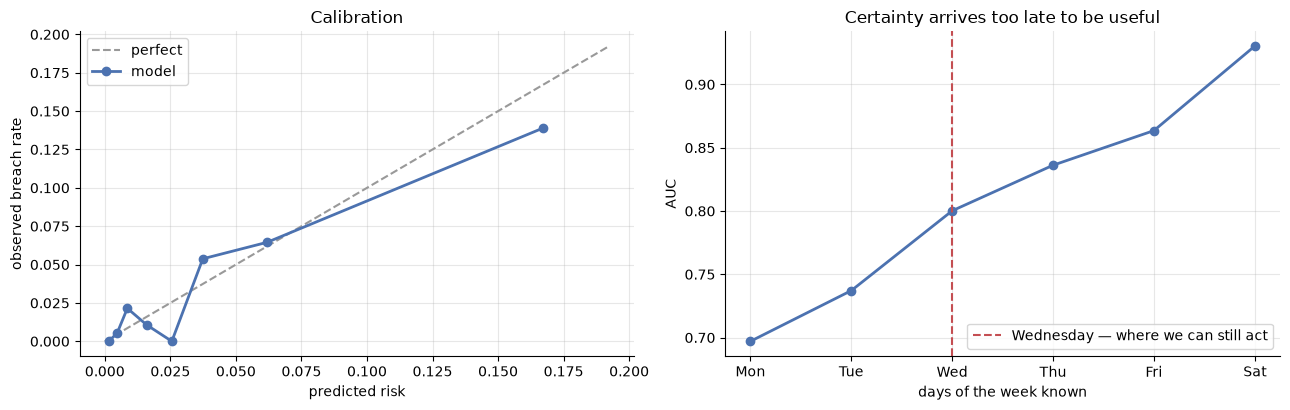

 days   auc
    1 0.697
    2 0.737
    3 0.800
    4 0.836
    5 0.864
    6 0.930


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
cal = wed.groupby(pd.qcut(wed.risk, 8, duplicates="drop"), observed=True).agg(
    predicted=("risk","mean"), actual=("breached","mean"))
lim = cal.predicted.max()*1.15
ax[0].plot([0,lim],[0,lim], ls="--", color="#999", label="perfect")
ax[0].plot(cal.predicted, cal.actual, "o-", color="#4C72B0", lw=2, label="model")
ax[0].set(title="Calibration", xlabel="predicted risk", ylabel="observed breach rate"); ax[0].legend()

by_day = pd.DataFrame([{"days": c, "auc": auc(g.breached, g.risk)} for c, g in oof.groupby("cut")])
ax[1].plot(by_day.days, by_day.auc, "o-", color="#4C72B0", lw=2)
ax[1].axvline(3, color="#C44E52", ls="--", label="Wednesday — where we can still act")
ax[1].set(title="Certainty arrives too late to be useful", xlabel="days of the week known",
          ylabel="AUC", xticks=range(1,7), xticklabels=["Mon","Tue","Wed","Thu","Fri","Sat"])
ax[1].legend(); plt.tight_layout(); plt.show()
print(by_day.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Calibration holds — mean predicted 0.040 against an actual rate of 0.037.

The right-hand plot is the honest summary of the problem. The same model on the same features gets
steadily better as the week goes on, and steadily less useful, because by Saturday the hours are
already worked. Wednesday is the trade: least information, but still time to change something.

## Where it goes wrong

In [12]:
flag = (wed.risk >= result.threshold).to_numpy().astype(int)
wed["outcome"] = np.select([(flag==1)&(y==1), (flag==0)&(y==1), (flag==1)&(y==0)],
                           ["caught","MISSED","false alarm"], "correctly quiet")
print(wed.groupby("outcome")[["hours_so_far","days_worked","prior_total",
                              "hours_remaining","week_total","risk"]].mean().round(2).to_string())
print()
print(wed.outcome.value_counts().to_string())

                 hours_so_far  days_worked  prior_total  hours_remaining  week_total  risk
outcome                                                                                   
MISSED                  21.72         2.07        45.64            35.63       57.35  0.04
caught                  28.56         2.85        47.37            29.06       57.62  0.18
correctly quiet         16.60         1.66        41.70            24.17       40.78  0.02
false alarm             29.26         2.91        45.56            15.95       45.21  0.17

outcome
correctly quiet    1279
false alarm         157
MISSED               29
caught               26


The misses and the false alarms are the same problem seen from both sides.

A **missed** breach looks ordinary on Wednesday — 21.7h over two days, close to the quiet group —
and then works **35.6h** across Thursday to Sunday. A **false alarm** looks alarming on Wednesday —
29.3h, more than the ones we correctly caught — and then works only **16.0h**.

Nearly identical visible evidence, opposite outcomes. That is not a tuning problem: whatever drives
those weekends has not happened yet when the call is made. It caps Wednesday prediction regardless
of model choice.

**Where I would not trust this output:** anything scoring between roughly 0.05 and 0.20. The top of
the list is genuinely elevated and the bottom genuinely safe, but the middle barely separates
anyone and its calibration rests on very few real breaches.

## This week

In [13]:
live, meta = predict_current_week(conn)
print(f"Week starting {meta['current_week_start']}, {meta['days_known']} days known — "
      f"flagged {meta['flagged_this_week']} of {meta['employees_scored']}\n")
print(live.head(10)[["employee_id","hours_so_far","days_worked","prior_total",
                     "exp_total","naive_projection","risk_score","will_breach"]]
      .round(2).to_string(index=False))

Week starting 2026-08-10, 3 days known — flagged 42 of 213

employee_id  hours_so_far  days_worked  prior_total  exp_total  naive_projection  risk_score  will_breach
      E1099         40.00          3.0        45.94      67.36             93.33        0.48            1
      E1042         36.25          3.0        48.64      64.83             84.58        0.44            1
      E1122         27.75          3.0        52.11      61.81             64.75        0.40            1
      E1044         36.00          3.0        49.00      62.56             84.00        0.37            1
      E1142         37.00          3.0        42.06      59.47             86.33        0.32            1
      E1087         35.50          3.0        41.25      62.64             82.83        0.30            1
      E1104         34.75          3.0        45.14      64.44             81.08        0.29            1
      E1061         28.25          3.0        51.58      63.67             65.92        0.29

Read the two projection columns together. For the person at the top the naive rule projects **93
hours** — impossible, and exactly why it flags a quarter of the workforce. `exp_total`, built from
that employee's own day-of-week history, says about **67** — over the line, and plausible.

Note that even the highest-risk person in the business scores below 0.5. That is correct, not
timidity: fewer than half the people who look like this on a Wednesday actually breach.